# Predictive Modeling — Classification (H2)

## Step 1: Load Dataset and Prepare Features

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import (train_test_split, cross_val_score, StratifiedKFold,
                                     GridSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../datasets/student_exam_features.csv')

# Drop identifiers, raw categoricals (already encoded), target columns, and derived targets
drop_cols = ['student_id', 'gender', 'parental_education', 'family_income',
             'internet_access', 'study_environment', 'tutoring',
             'pass_fail', 'grade_category', 'pass_fail_enc',
             'final_exam_score']

X = df.drop(columns=drop_cols, errors='ignore')

# Drop one-hot grade columns (derived from target)
grade_cols = [c for c in X.columns if c.startswith('grade_')]
X = X.drop(columns=grade_cols, errors='ignore')

y = df['pass_fail_enc']

print(f"Features: {X.shape}")
print(f"Feature names: {list(X.columns)}")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features: (10000, 19)
Feature names: ['age', 'study_hours_per_day', 'attendance_rate', 'sleep_hours', 'social_media_hours', 'assignment_completion_rate', 'online_courses_completed', 'previous_gpa', 'internet_access_enc', 'tutoring_enc', 'gender_enc', 'parental_education_enc', 'family_income_enc', 'study_environment_enc', 'productive_hours', 'study_attendance', 'engagement_score', 'disadvantage_index', 'social_study_ratio']

Target distribution:
pass_fail_enc
0    5142
1    4858
Name: count, dtype: int64


## Step 2: Train/Test Split

In [2]:
RANDOM_STATE = 42

# stratify=y keeps the Pass/Fail ratio identical in train and test (not left to chance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print(f"Train/test: {X_train.shape} / {X_test.shape}")
print(f"Train target distribution:\n{y_train.value_counts(normalize=True).round(4)}")
print(f"Test target distribution:\n{y_test.value_counts(normalize=True).round(4)}")

Train/test: (8000, 19) / (2000, 19)
Train target distribution:
pass_fail_enc
0    0.5142
1    0.4858
Name: proportion, dtype: float64
Test target distribution:
pass_fail_enc
0    0.514
1    0.486
Name: proportion, dtype: float64


## Step 3: Scale Features

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled using StandardScaler")

Features scaled using StandardScaler


## Step 4: Logistic Regression

In [4]:
cls_results = {}

log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)
y_pred_lr = log_reg.predict(X_test_scaled)

cls_results['Logistic Regression'] = {
    'model': log_reg,
    'y_pred': y_pred_lr,
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
}

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr, target_names=['Fail', 'Pass']))

Logistic Regression:
              precision    recall  f1-score   support

        Fail       0.86      0.89      0.87      1028
        Pass       0.88      0.84      0.86       972

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



## Step 5: Random Forest Classifier

In [5]:
rf_cls = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)
rf_cls.fit(X_train, y_train)
y_pred_rf = rf_cls.predict(X_test)

cls_results['Random Forest'] = {
    'model': rf_cls,
    'y_pred': y_pred_rf,
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf),
    'recall': recall_score(y_test, y_pred_rf),
    'f1': f1_score(y_test, y_pred_rf),
}

print("Random Forest Classifier:")
print(classification_report(y_test, y_pred_rf, target_names=['Fail', 'Pass']))

Random Forest Classifier:
              precision    recall  f1-score   support

        Fail       0.85      0.87      0.86      1028
        Pass       0.86      0.84      0.85       972

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



## Step 6: 5-Fold Stratified Cross-Validation

In [6]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_cv = cross_val_score(LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                        X_train_scaled, y_train, cv=cv, scoring='accuracy')
rf_cv = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
                        X_train, y_train, cv=cv, scoring='accuracy')

print(f"Logistic Regression CV accuracy: {lr_cv.mean():.4f} +/- {lr_cv.std():.4f}")
print(f"Random Forest CV accuracy:       {rf_cv.mean():.4f} +/- {rf_cv.std():.4f}")

Logistic Regression CV accuracy: 0.8601 +/- 0.0039
Random Forest CV accuracy:       0.8510 +/- 0.0050


## Step 6A: Hyperparameter Tuning with GridSearchCV (M2)

In [7]:
# --- Logistic Regression Tuning ---
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear'],
    'max_iter': [1000],
}
lr_grid = GridSearchCV(
    LogisticRegression(random_state=RANDOM_STATE),
    lr_param_grid, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True
)
lr_grid.fit(X_train_scaled, y_train)

print(f"Logistic Regression Best Parameters: {lr_grid.best_params_}")
print(f"LR Best CV Accuracy: {lr_grid.best_score_:.4f}")

# --- Random Forest Tuning ---
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    rf_param_grid, cv=cv, scoring='accuracy', n_jobs=-1, return_train_score=True
)
rf_grid.fit(X_train, y_train)

print(f"\nRandom Forest Best Parameters: {rf_grid.best_params_}")
print(f"RF Best CV Accuracy: {rf_grid.best_score_:.4f}")

# --- Evaluate tuned models on test set ---
log_reg_tuned = lr_grid.best_estimator_
y_pred_lr_tuned = log_reg_tuned.predict(X_test_scaled)

rf_tuned = rf_grid.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test)

# --- Comparison: Default vs Tuned ---
print("\n" + "=" * 90)
print("HYPERPARAMETER TUNING COMPARISON")
print("=" * 90)
print(f"\n{'Model':<35} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12}")
print('-' * 83)

for name, res in cls_results.items():
    print(f"{name:<35} {res['accuracy']:<12.4f} {res['precision']:<12.4f} {res['recall']:<12.4f} {res['f1']:<12.4f}")

tuned_lr_acc = accuracy_score(y_test, y_pred_lr_tuned)
tuned_lr_prec = precision_score(y_test, y_pred_lr_tuned)
tuned_lr_rec = recall_score(y_test, y_pred_lr_tuned)
tuned_lr_f1 = f1_score(y_test, y_pred_lr_tuned)

tuned_rf_acc = accuracy_score(y_test, y_pred_rf_tuned)
tuned_rf_prec = precision_score(y_test, y_pred_rf_tuned)
tuned_rf_rec = recall_score(y_test, y_pred_rf_tuned)
tuned_rf_f1 = f1_score(y_test, y_pred_rf_tuned)

print(f"{'LR (Tuned)':<35} {tuned_lr_acc:<12.4f} {tuned_lr_prec:<12.4f} {tuned_lr_rec:<12.4f} {tuned_lr_f1:<12.4f}")
print(f"{'RF (Tuned)':<35} {tuned_rf_acc:<12.4f} {tuned_rf_prec:<12.4f} {tuned_rf_rec:<12.4f} {tuned_rf_f1:<12.4f}")

# Update cls_results to use tuned models for downstream steps
cls_results['Logistic Regression'] = {
    'model': log_reg_tuned,
    'y_pred': y_pred_lr_tuned,
    'accuracy': tuned_lr_acc,
    'precision': tuned_lr_prec,
    'recall': tuned_lr_rec,
    'f1': tuned_lr_f1,
}
cls_results['Random Forest'] = {
    'model': rf_tuned,
    'y_pred': y_pred_rf_tuned,
    'accuracy': tuned_rf_acc,
    'precision': tuned_rf_prec,
    'recall': tuned_rf_rec,
    'f1': tuned_rf_f1,
}
print("\ncls_results updated to use tuned models.")

Logistic Regression Best Parameters: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
LR Best CV Accuracy: 0.8610



Random Forest Best Parameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
RF Best CV Accuracy: 0.8562

HYPERPARAMETER TUNING COMPARISON

Model                               Accuracy     Precision    Recall       F1          
-----------------------------------------------------------------------------------
Logistic Regression                 0.8665       0.8762       0.8447       0.8601      
Random Forest                       0.8575       0.8604       0.8436       0.8519      
LR (Tuned)                          0.8705       0.8780       0.8519       0.8648      
RF (Tuned)                          0.8605       0.8651       0.8447       0.8548      

cls_results updated to use tuned models.


## Step 7: Confusion Matrices

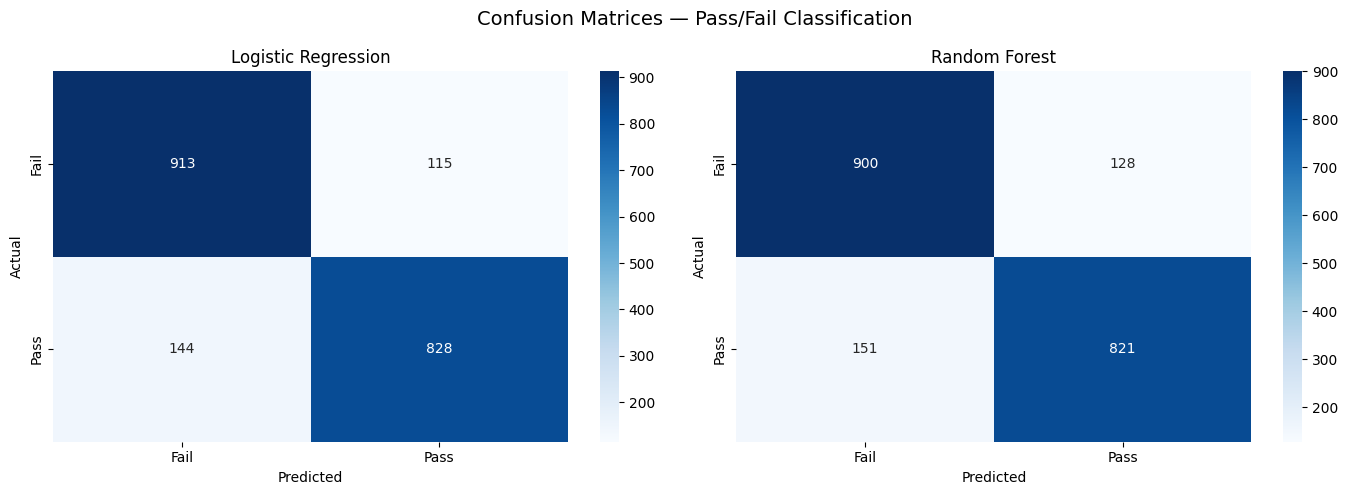

Figure saved: 12_confusion_matrices.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, cls_results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
    ax.set_title(f'{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Pass/Fail Classification', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/12_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 12_confusion_matrices.png")

## Step 7A: ROC-AUC Analysis (C3)

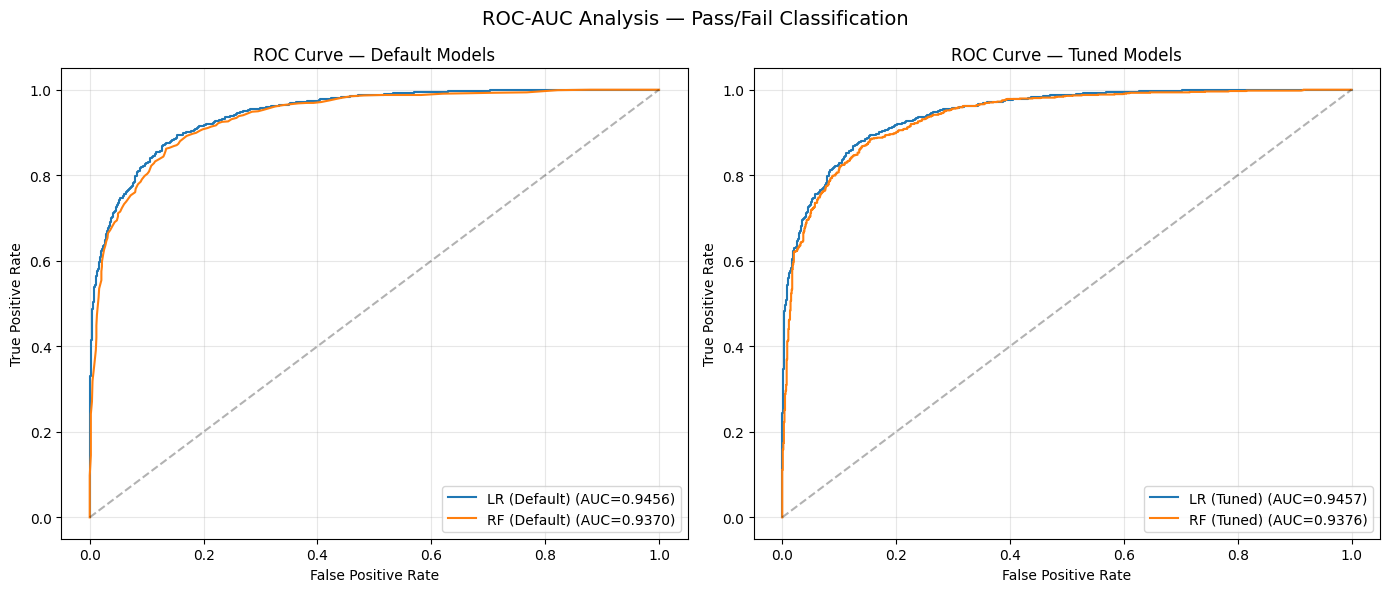

ROC-AUC Scores:
  LR (Default): 0.9456
  RF (Default): 0.9370
  LR (Tuned): 0.9457
  RF (Tuned): 0.9376

Figure saved: 19_roc_auc_curves.png


In [9]:
# ROC-AUC for default models (re-fit to get predict_proba)
y_prob_lr_default = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE).fit(
    X_train_scaled, y_train).predict_proba(X_test_scaled)[:, 1]
y_prob_rf_default = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1).fit(
    X_train, y_train).predict_proba(X_test)[:, 1]

# ROC-AUC for tuned models
y_prob_lr_tuned = log_reg_tuned.predict_proba(X_test_scaled)[:, 1]
y_prob_rf_tuned = rf_tuned.predict_proba(X_test)[:, 1]

# Compute curves and AUC
roc_data = {}
for name, y_prob in [('LR (Default)', y_prob_lr_default), ('RF (Default)', y_prob_rf_default),
                      ('LR (Tuned)', y_prob_lr_tuned), ('RF (Tuned)', y_prob_rf_tuned)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    roc_data[name] = {'fpr': fpr, 'tpr': tpr, 'auc': auc}

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for name in ['LR (Default)', 'RF (Default)']:
    d = roc_data[name]
    axes[0].plot(d['fpr'], d['tpr'], label=f"{name} (AUC={d['auc']:.4f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve — Default Models')
axes[0].legend()
axes[0].grid(alpha=0.3)

for name in ['LR (Tuned)', 'RF (Tuned)']:
    d = roc_data[name]
    axes[1].plot(d['fpr'], d['tpr'], label=f"{name} (AUC={d['auc']:.4f})")
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Tuned Models')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('ROC-AUC Analysis — Pass/Fail Classification', fontsize=14)
plt.tight_layout()
plt.savefig('../deliverables/figures/19_roc_auc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("ROC-AUC Scores:")
for name, d in roc_data.items():
    print(f"  {name}: {d['auc']:.4f}")
print(f"\nFigure saved: 19_roc_auc_curves.png")

## Step 8: Random Forest Feature Importance

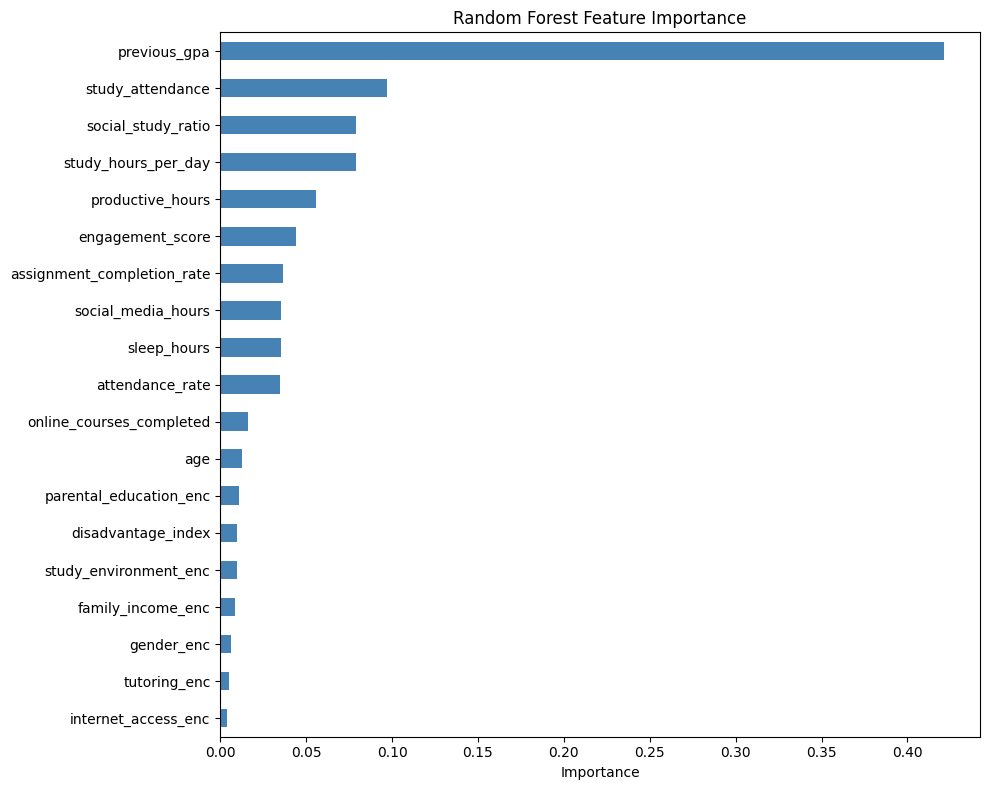

Figure saved: 13_rf_feature_importance.png

Top 5 most important features:
  previous_gpa: 0.4212
  study_attendance: 0.0969
  social_study_ratio: 0.0790
  study_hours_per_day: 0.0788
  productive_hours: 0.0555


In [10]:
feat_imp = pd.Series(rf_cls.feature_importances_, index=X.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp.plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../deliverables/figures/13_rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: 13_rf_feature_importance.png")
print(f"\nTop 5 most important features:")
for feat, imp in feat_imp.tail(5)[::-1].items():
    print(f"  {feat}: {imp:.4f}")

## Step 8A: Ablation Study — Effect of previous_gpa (C2)

Full features: 19, Ablation features: 18



ABLATION STUDY: Effect of previous_gpa on Classification Performance

Model                          Accuracy     Precision    Recall       F1           CV Acc      
------------------------------------------------------------------------------------------
LR (Full)                      0.8705       0.8780       0.8519       0.8648       0.8610      
LR (no previous_gpa)           0.7575       0.7560       0.7397       0.7478       0.7338      
RF (Full)                      0.8605       0.8651       0.8447       0.8548       0.8562      
RF (no previous_gpa)           0.7410       0.7395       0.7212       0.7302       0.7280      

Accuracy drop without previous_gpa:
  Logistic Regression: +0.1130 (+13.0%)
  Random Forest:       +0.1195 (+13.9%)

previous_gpa contributes ~13.9% of RF accuracy and ~13.0% of LR accuracy.
This confirms previous_gpa's dominance and highlights the need for behavioral features
as the primary basis for actionable interventions.


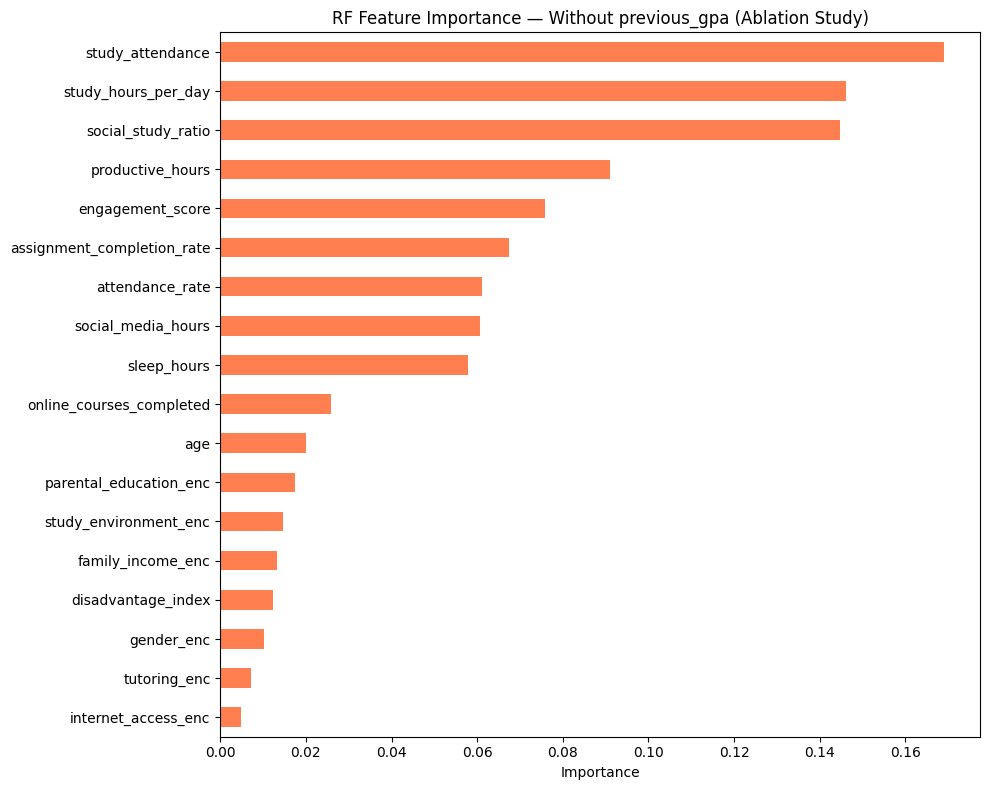

Figure saved: 20_ablation_rf_importance_no_gpa.png

Top 5 behavioral features (without previous_gpa):
  study_attendance: 0.1690
  study_hours_per_day: 0.1460
  social_study_ratio: 0.1448
  productive_hours: 0.0910
  engagement_score: 0.0758


In [11]:
# --- Ablation: Remove previous_gpa ---
X_train_no_gpa = X_train.drop(columns=['previous_gpa'])
X_test_no_gpa = X_test.drop(columns=['previous_gpa'])
print(f"Full features: {X_train.shape[1]}, Ablation features: {X_train_no_gpa.shape[1]}")

# Scale for LR (must refit scaler on reduced feature set)
scaler_no_gpa = StandardScaler()
X_train_no_gpa_scaled = scaler_no_gpa.fit_transform(X_train_no_gpa)
X_test_no_gpa_scaled = scaler_no_gpa.transform(X_test_no_gpa)

# LR without previous_gpa (using tuned hyperparameters from GridSearchCV)
lr_best_params = {k: v for k, v in lr_grid.best_params_.items() if k != 'max_iter'}
lr_ablation = LogisticRegression(**lr_best_params, max_iter=1000, random_state=RANDOM_STATE)
lr_ablation.fit(X_train_no_gpa_scaled, y_train)
y_pred_lr_ablation = lr_ablation.predict(X_test_no_gpa_scaled)

# RF without previous_gpa (using tuned hyperparameters from GridSearchCV)
rf_best_params = {k: v for k, v in rf_grid.best_params_.items() if k not in ('n_jobs',)}
rf_ablation = RandomForestClassifier(**rf_best_params, random_state=RANDOM_STATE, n_jobs=-1)
rf_ablation.fit(X_train_no_gpa, y_train)
y_pred_rf_ablation = rf_ablation.predict(X_test_no_gpa)

# CV scores without previous_gpa
lr_cv_no_gpa = cross_val_score(
    LogisticRegression(**lr_best_params, max_iter=1000, random_state=RANDOM_STATE),
    X_train_no_gpa_scaled, y_train, cv=cv, scoring='accuracy')
rf_cv_no_gpa = cross_val_score(
    RandomForestClassifier(**rf_best_params, random_state=RANDOM_STATE, n_jobs=-1),
    X_train_no_gpa, y_train, cv=cv, scoring='accuracy')

# --- Results Table ---
print("\n" + "=" * 100)
print("ABLATION STUDY: Effect of previous_gpa on Classification Performance")
print("=" * 100)
print(f"\n{'Model':<30} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1':<12} {'CV Acc':<12}")
print('-' * 90)

models_ablation = [
    ('LR (Full)', y_pred_lr_tuned, lr_grid.best_score_),
    ('LR (no previous_gpa)', y_pred_lr_ablation, lr_cv_no_gpa.mean()),
    ('RF (Full)', y_pred_rf_tuned, rf_grid.best_score_),
    ('RF (no previous_gpa)', y_pred_rf_ablation, rf_cv_no_gpa.mean()),
]
for name, y_pred, cv_acc in models_ablation:
    print(f"{name:<30} {accuracy_score(y_test, y_pred):<12.4f} "
          f"{precision_score(y_test, y_pred):<12.4f} {recall_score(y_test, y_pred):<12.4f} "
          f"{f1_score(y_test, y_pred):<12.4f} {cv_acc:<12.4f}")

# --- Accuracy Drop ---
lr_drop = tuned_lr_acc - accuracy_score(y_test, y_pred_lr_ablation)
rf_drop = tuned_rf_acc - accuracy_score(y_test, y_pred_rf_ablation)
lr_pct = lr_drop / tuned_lr_acc * 100
rf_pct = rf_drop / tuned_rf_acc * 100

print(f"\nAccuracy drop without previous_gpa:")
print(f"  Logistic Regression: {lr_drop:+.4f} ({lr_pct:+.1f}%)")
print(f"  Random Forest:       {rf_drop:+.4f} ({rf_pct:+.1f}%)")
print(f"\nprevious_gpa contributes ~{rf_pct:.1f}% of RF accuracy and ~{lr_pct:.1f}% of LR accuracy.")
print("This confirms previous_gpa's dominance and highlights the need for behavioral features")
print("as the primary basis for actionable interventions.")

# --- RF Feature Importance without previous_gpa ---
feat_imp_no_gpa = pd.Series(rf_ablation.feature_importances_,
                             index=X_train_no_gpa.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(10, 8))
feat_imp_no_gpa.plot(kind='barh', color='coral', ax=ax)
ax.set_title('RF Feature Importance — Without previous_gpa (Ablation Study)')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('../deliverables/figures/20_ablation_rf_importance_no_gpa.png', dpi=150, bbox_inches='tight')
plt.show()

print("Figure saved: 20_ablation_rf_importance_no_gpa.png")
print(f"\nTop 5 behavioral features (without previous_gpa):")
for feat, imp in feat_imp_no_gpa.tail(5)[::-1].items():
    print(f"  {feat}: {imp:.4f}")

## Step 9: H2 Evaluation — Random Forest vs Logistic Regression

In [12]:
print("=" * 70)
print("H2 Evaluation: Random Forest vs Logistic Regression (Tuned)")
print("=" * 70)
print(f"\nNote: Using GridSearchCV-tuned models.")
print(f"LR best params: {lr_grid.best_params_}")
print(f"RF best params: {rf_grid.best_params_}")

print(f"\n{'Metric':<12} {'Logistic Regression':<22} {'Random Forest':<22} {'Winner'}")
print('-' * 70)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    lr_val = cls_results['Logistic Regression'][metric]
    rf_val = cls_results['Random Forest'][metric]
    winner = 'RF' if rf_val > lr_val else 'LR' if lr_val > rf_val else 'Tie'
    print(f"{metric:<12} {lr_val:<22.4f} {rf_val:<22.4f} {winner}")

# --- Model comparison on CV scores ---
from scipy import stats
lr_tuned_cv = cross_val_score(log_reg_tuned, X_train_scaled, y_train, cv=cv, scoring='accuracy')
rf_tuned_cv = cross_val_score(rf_tuned, X_train, y_train, cv=cv, scoring='accuracy')

# Standard paired t-test (reported for reference only).
# It is known to be optimistic for k-fold CV because the training folds overlap,
# violating the independence assumption -> variance underestimated, |t| inflated.
t_naive, p_naive = stats.ttest_rel(rf_tuned_cv, lr_tuned_cv)

# Corrected resampled t-test (Nadeau & Bengio, 2003): inflates the variance by
# (1/k + n_test/n_train) to account for the dependence between overlapping CV folds.
def corrected_resampled_ttest(diffs, n_train, n_test):
    k = len(diffs)
    mean_d = np.mean(diffs)
    var_d = np.var(diffs, ddof=1)
    correction = (1.0 / k) + (n_test / n_train)
    t = mean_d / np.sqrt(correction * var_d)
    df = k - 1
    p = 2 * stats.t.sf(np.abs(t), df)
    return t, p, df

diffs = rf_tuned_cv - lr_tuned_cv          # positive => RF better than LR
n_test_fold = len(X_train) // cv.get_n_splits()
n_train_fold = len(X_train) - n_test_fold
t_corr, p_corr, df_corr = corrected_resampled_ttest(diffs, n_train_fold, n_test_fold)

print(f"\nCV Accuracy: LR={lr_tuned_cv.mean():.4f}, RF={rf_tuned_cv.mean():.4f} "
      f"(mean diff RF-LR = {diffs.mean():+.4f})")
print(f"Naive paired t-test (reference): t={t_naive:.4f}, p={p_naive:.4f}, df={len(diffs)-1}")
print(f"Corrected resampled t-test (Nadeau-Bengio): t={t_corr:.4f}, p={p_corr:.4f}, df={df_corr}")

# --- H2 decision ---
# H2 hypothesis is DIRECTIONAL: "RF outperforms LR". It is supported ONLY if RF is
# both higher AND significantly so (corrected test).
rf_better = rf_tuned_cv.mean() > lr_tuned_cv.mean()
sig = p_corr < 0.05
if sig and rf_better:
    h2_result = "DIDUKUNG"
    h2_msg = "RF secara signifikan mengungguli LR pada CV."
elif sig and not rf_better:
    h2_result = "TIDAK DIDUKUNG (LR > RF, signifikan)"
    h2_msg = (f"Arah berlawanan dengan hipotesis: LR justru SIGNIFIKAN lebih baik dari RF "
              f"(corrected t-test p={p_corr:.4f}). Hipotesis 'RF > LR' ditolak.")
else:
    h2_result = "TIDAK DIDUKUNG (model setara)"
    h2_msg = ("Perbedaan RF-LR tidak signifikan (corrected t-test); "
              "kedua model setara secara statistik.")

print(f"\nH2 ({h2_result}): {h2_msg}")

H2 Evaluation: Random Forest vs Logistic Regression (Tuned)

Note: Using GridSearchCV-tuned models.
LR best params: {'C': 0.1, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}
RF best params: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}

Metric       Logistic Regression    Random Forest          Winner
----------------------------------------------------------------------
accuracy     0.8705                 0.8605                 LR
precision    0.8780                 0.8651                 LR
recall       0.8519                 0.8447                 LR
f1           0.8648                 0.8548                 LR



CV Accuracy: LR=0.8610, RF=0.8562 (mean diff RF-LR = -0.0048)
Naive paired t-test (reference): t=-4.4940, p=0.0109, df=4
Corrected resampled t-test (Nadeau-Bengio): t=-2.9960, p=0.0401, df=4

H2 (TIDAK DIDUKUNG (LR > RF, signifikan)): Arah berlawanan dengan hipotesis: LR justru SIGNIFIKAN lebih baik dari RF (corrected t-test p=0.0401). Hipotesis 'RF > LR' ditolak.


In [13]:
# Step 9b: Persist model results as a single source of truth for notebook 10
import json

model_results = {
    'lr': {'accuracy': tuned_lr_acc, 'precision': tuned_lr_prec, 'recall': tuned_lr_rec,
           'f1': tuned_lr_f1, 'cv': float(lr_tuned_cv.mean())},
    'rf': {'accuracy': tuned_rf_acc, 'precision': tuned_rf_prec, 'recall': tuned_rf_rec,
           'f1': tuned_rf_f1, 'cv': float(rf_tuned_cv.mean())},
    'h2': {'t_naive': float(t_naive), 'p_naive': float(p_naive),
           't_corr': float(t_corr), 'p_corr': float(p_corr), 'df': int(df_corr),
           'result': h2_result, 'rf_better': bool(rf_better)},
    'roc_auc': {k: float(v['auc']) for k, v in roc_data.items()},
    'feature_importance': {k: float(v) for k, v in feat_imp.tail(5)[::-1].items()},
    'ablation': {
        'lr_full': float(tuned_lr_acc),
        'lr_no_gpa': float(accuracy_score(y_test, y_pred_lr_ablation)),
        'rf_full': float(tuned_rf_acc),
        'rf_no_gpa': float(accuracy_score(y_test, y_pred_rf_ablation)),
    },
}
with open('../datasets/model_results.json', 'w') as f:
    json.dump(model_results, f, indent=2)
print("Saved ../datasets/model_results.json (consumed by notebook 10)")
print(json.dumps(model_results, indent=2))

Saved ../datasets/model_results.json (consumed by notebook 10)
{
  "lr": {
    "accuracy": 0.8705,
    "precision": 0.8780487804878049,
    "recall": 0.8518518518518519,
    "f1": 0.8647519582245431,
    "cv": 0.861
  },
  "rf": {
    "accuracy": 0.8605,
    "precision": 0.8651211801896733,
    "recall": 0.8446502057613169,
    "f1": 0.8547631441957314,
    "cv": 0.85625
  },
  "h2": {
    "t_naive": -4.493974209517021,
    "p_naive": 0.010872630067986432,
    "t_corr": -2.9959828063446805,
    "p_corr": 0.040100560597838716,
    "df": 4,
    "result": "TIDAK DIDUKUNG (LR > RF, signifikan)",
    "rf_better": false
  },
  "roc_auc": {
    "LR (Default)": 0.9456003506749292,
    "RF (Default)": 0.9369705849385919,
    "LR (Tuned)": 0.9457144401210549,
    "RF (Tuned)": 0.9375935733615154
  },
  "feature_importance": {
    "previous_gpa": 0.4211764225422543,
    "study_attendance": 0.09690196434672352,
    "social_study_ratio": 0.0790154144433586,
    "study_hours_per_day": 0.078785133717